# 02 — DCGAN

Deep Convolutional GAN (2014) — vanilla baseline for chest X-ray generation.

**Architecture:** Generator uses transposed convolutions to upsample noise. Discriminator uses strided convolutions to classify real vs fake.

**Reference:** kaledhoshme123/Using-GAN-to-Generate-Chest-X-Ray-Images

## Setup

In [46]:
!pip install torchxrayvision -q
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy import linalg

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [47]:
# hyperparameters
IMG_SIZE = 64
CHANNELS = 1
NOISE_DIM = 100
FEATURE_G = 64
FEATURE_D = 64
BATCH_SIZE = 32
LR = 0.0002
BETA1 = 0.5
N_EPOCHS = 50
N_GENERATE = 100

In [48]:
# paths
# DATA_DIR = Path("../data") # its for local
DATA_DIR = Path("/kaggle/input/datasets/lakshyarathi/lungpp/data")
REAL_DIR = DATA_DIR / "pneumonia"

OUTPUT_DIR = Path("outputs/02_dcgan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Loading

In [49]:
class XrayDataset(Dataset):
    def __init__(self, folder: Path, transform=None):
        self.paths = sorted([
            p for p in folder.iterdir()
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and not p.name.startswith('.')
        ])
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

In [50]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # scale to [-1, 1] for tanh output
])

dataset = XrayDataset(REAL_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 3875
Batches per epoch: 121


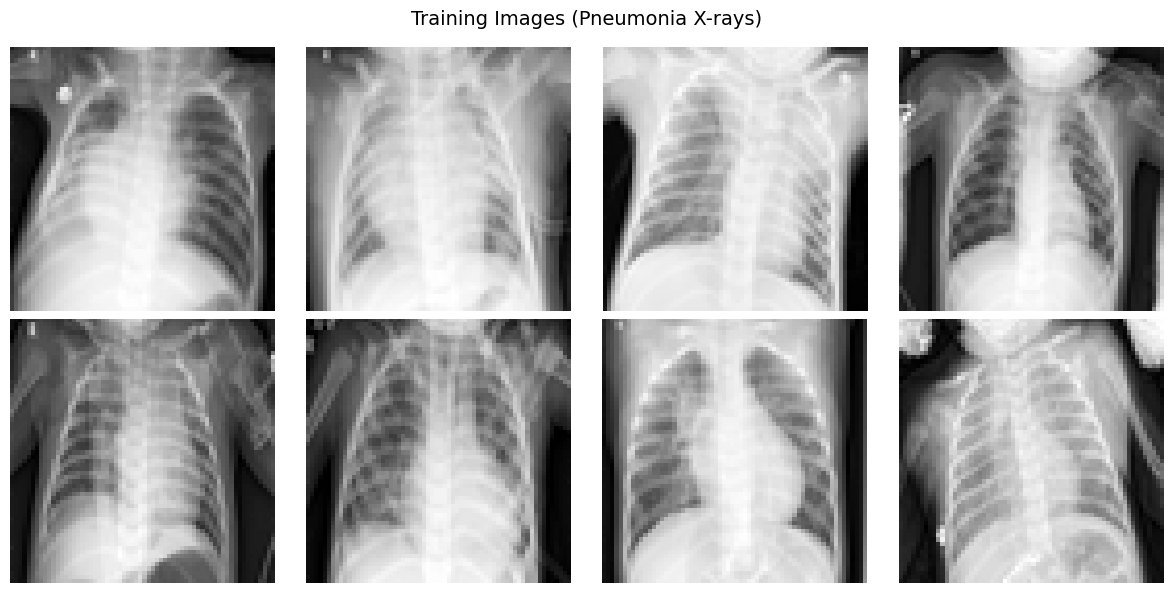

In [51]:
# visualize some training images
sample_batch = next(iter(dataloader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Training Images (Pneumonia X-rays)", fontsize=14)

for ax, img in zip(axes.flat, sample_batch[:8]):
    # denormalize from [-1, 1] to [0, 1]
    img = (img.squeeze() + 1) / 2
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Model Architecture

**Generator:** noise → 4x4 → 8x8 → 16x16 → 32x32 → 64x64 image

**Discriminator:** 64x64 image → 32x32 → 16x16 → 8x8 → 4x4 → real/fake

In [52]:
def weights_init(m):
    """Initialize weights as per DCGAN paper."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [53]:
class Generator(nn.Module):
    def __init__(self, noise_dim, channels, feature_g):
        super().__init__()
        self.main = nn.Sequential(
            # noise_dim -> feature_g*8 x 4 x 4
            nn.ConvTranspose2d(noise_dim, feature_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 8),
            nn.ReLU(True),
            
            # feature_g*8 x 4 x 4 -> feature_g*4 x 8 x 8
            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            
            # feature_g*4 x 8 x 8 -> feature_g*2 x 16 x 16
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            
            # feature_g*2 x 16 x 16 -> feature_g x 32 x 32
            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            
            # feature_g x 32 x 32 -> channels x 64 x 64
            nn.ConvTranspose2d(feature_g, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    
    def forward(self, x):
        return self.main(x)

In [54]:
class Discriminator(nn.Module):
    def __init__(self, channels, feature_d):
        super().__init__()
        self.main = nn.Sequential(
            # channels x 64 x 64 -> feature_d x 32 x 32
            nn.Conv2d(channels, feature_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # feature_d x 32 x 32 -> feature_d*2 x 16 x 16
            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # feature_d*2 x 16 x 16 -> feature_d*4 x 8 x 8
            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # feature_d*4 x 8 x 8 -> feature_d*8 x 4 x 4
            nn.Conv2d(feature_d * 4, feature_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # feature_d*8 x 4 x 4 -> 1 x 1 x 1
            nn.Conv2d(feature_d * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

In [55]:
# initialize models
netG = Generator(NOISE_DIM, CHANNELS, FEATURE_G).to(device)
netD = Discriminator(CHANNELS, FEATURE_D).to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(f"Generator parameters: {sum(p.numel() for p in netG.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in netD.parameters()):,}")

Generator parameters: 3,574,656
Discriminator parameters: 2,763,520


## Training

In [56]:
criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

# fixed noise for visualization during training
fixed_noise = torch.randn(16, NOISE_DIM, 1, 1, device=device)

In [57]:
# training history
G_losses = []
D_losses = []

print("Starting training...")

for epoch in range(N_EPOCHS):
    epoch_G_loss = 0.0
    epoch_D_loss = 0.0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    
    for i, real_images in enumerate(pbar):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)
        
        # labels
        real_label = torch.ones(batch_size, device=device)
        fake_label = torch.zeros(batch_size, device=device)
        
        # ---------------------
        # Train Discriminator
        # ---------------------
        netD.zero_grad()
        
        # real batch
        output_real = netD(real_images)
        lossD_real = criterion(output_real, real_label)
        
        # fake batch
        noise = torch.randn(batch_size, NOISE_DIM, 1, 1, device=device)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, fake_label)
        
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()
        
        # ---------------------
        # Train Generator
        # ---------------------
        netG.zero_grad()
        
        # generator wants discriminator to think fakes are real
        output = netD(fake_images)
        lossG = criterion(output, real_label)
        lossG.backward()
        optimizerG.step()
        
        epoch_G_loss += lossG.item()
        epoch_D_loss += lossD.item()
        
        pbar.set_postfix({'D_loss': f'{lossD.item():.4f}', 'G_loss': f'{lossG.item():.4f}'})
    
    # average losses for epoch
    avg_G_loss = epoch_G_loss / len(dataloader)
    avg_D_loss = epoch_D_loss / len(dataloader)
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)
    
    print(f"Epoch {epoch+1}: D_loss={avg_D_loss:.4f}, G_loss={avg_G_loss:.4f}")
    
    # save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'netG_state_dict': netG.state_dict(),
            'netD_state_dict': netD.state_dict(),
            'optimizerG_state_dict': optimizerG.state_dict(),
            'optimizerD_state_dict': optimizerD.state_dict(),
            'G_losses': G_losses,
            'D_losses': D_losses,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

print("Training complete!")

Starting training...


Epoch 1/50: 100%|██████████| 121/121 [00:09<00:00, 13.22it/s, D_loss=0.3386, G_loss=6.5789] 


Epoch 1: D_loss=0.7907, G_loss=11.1520


Epoch 2/50: 100%|██████████| 121/121 [00:05<00:00, 22.83it/s, D_loss=0.4916, G_loss=3.7749]


Epoch 2: D_loss=0.7131, G_loss=4.8936


...

Epoch 48: D_loss=0.1446, G_loss=6.0730


Epoch 49/50: 100%|██████████| 121/121 [00:05<00:00, 20.25it/s, D_loss=0.1910, G_loss=5.3789] 


Epoch 49: D_loss=0.5259, G_loss=7.6141


Epoch 50/50: 100%|██████████| 121/121 [00:05<00:00, 20.22it/s, D_loss=0.1390, G_loss=4.8238]


Epoch 50: D_loss=0.1927, G_loss=5.7132
Saved checkpoint: outputs/02_dcgan/checkpoints/checkpoint_epoch_50.pt
Training complete!


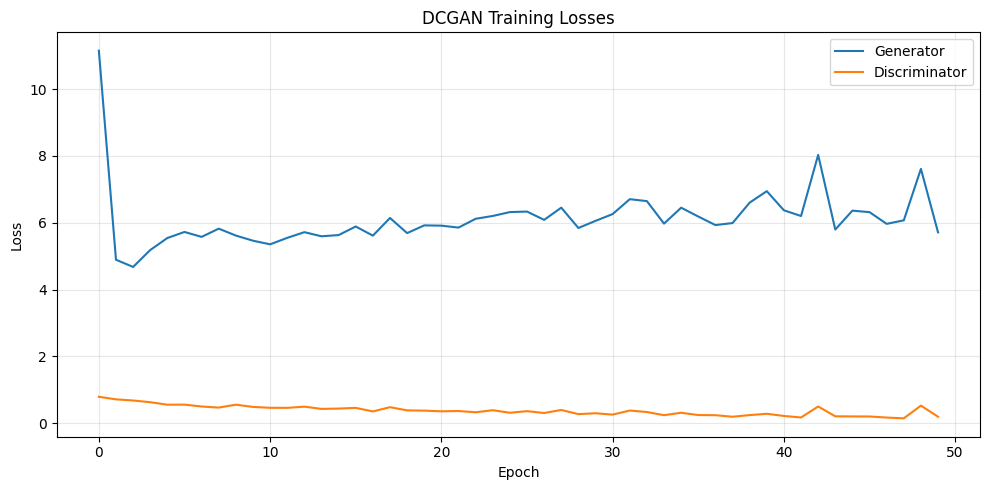

In [58]:
# plot training curves
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator')
plt.plot(D_losses, label='Discriminator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150)
plt.show()

## Generate 100 Images

In [59]:
generated_dir = OUTPUT_DIR / "images"
generated_dir.mkdir(parents=True, exist_ok=True)

netG.eval()
generated_paths = []

with torch.no_grad():
    for i in tqdm(range(N_GENERATE), desc="Generating"):
        noise = torch.randn(1, NOISE_DIM, 1, 1, device=device)
        fake = netG(noise)
        
        # denormalize from [-1, 1] to [0, 255]
        img = fake.squeeze().cpu().numpy()
        img = ((img + 1) / 2 * 255).astype(np.uint8)
        img = Image.fromarray(img, mode='L')
        
        out_path = generated_dir / f"{i:04d}.png"
        img.save(out_path, 'PNG')
        generated_paths.append(out_path)

print(f"Generated {len(generated_paths)} images")

Generating: 100%|██████████| 100/100 [00:00<00:00, 752.00it/s]

Generated 100 images


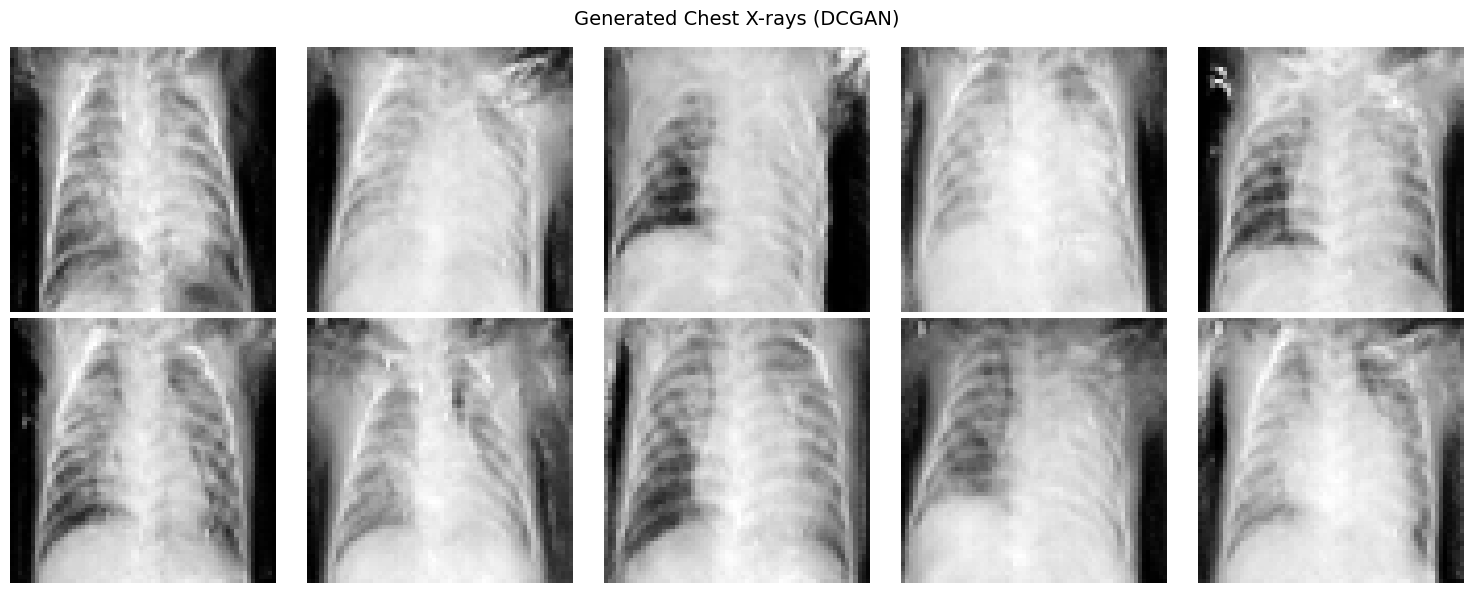

In [60]:
# visualize generated images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Generated Chest X-rays (DCGAN)", fontsize=14)

for ax, img_path in zip(axes.flat, generated_paths[:10]):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "generated_samples.png", dpi=150)
plt.show()

## Evaluate — FID (domain-adapted, DenseNet121 features)

FID computed using torchxrayvision DenseNet121 features instead of Inception V3.

In [61]:
# load torchxrayvision model for feature extraction
xrv_model = xrv.models.DenseNet(weights="densenet121-res224-all")
xrv_model = xrv_model.to(device)
xrv_model.eval()

# use features (before classification head)
feature_extractor = nn.Sequential(*list(xrv_model.features.children()))
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(

In [62]:
def load_and_preprocess_for_xrv(img_path):
    """Load image and preprocess for torchxrayvision (224x224, normalized)."""
    img = Image.open(img_path).convert('L')
    img = img.resize((224, 224), Image.LANCZOS)
    img = np.array(img, dtype=np.float32)
    # xrv expects [-1024, 1024] range
    img = (img / 255.0) * 2048 - 1024
    img = img[np.newaxis, ...]
    return torch.tensor(img, dtype=torch.float32)


def extract_features(image_paths, batch_size=32):
    """Extract DenseNet121 features from images."""
    features = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        
        with torch.no_grad():
            feat = feature_extractor(batch)
            feat = feat.mean(dim=[2, 3])  # global average pooling
            features.append(feat.cpu().numpy())
    
    return np.concatenate(features, axis=0)


def compute_fid(real_features, fake_features):
    """Compute FID between two sets of features."""
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    
    diff = mu_real - mu_fake
    covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return float(fid)

In [63]:
# get real image paths
real_paths = sorted([
    p for p in REAL_DIR.iterdir()
    if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and not p.name.startswith('.')
])

# sample 100 real images for FID
random.seed(SEED)
real_sample = random.sample(real_paths, N_GENERATE)

print("Extracting features from real images...")
real_features = extract_features(real_sample)

print("Extracting features from generated images...")
fake_features = extract_features(generated_paths)

fid_score = compute_fid(real_features, fake_features)
print(f"\nDomain-adapted FID (DenseNet121): {fid_score:.2f}")

Extracting features from real images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  5.96it/s]


Extracting features from generated images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00, 10.28it/s]



Domain-adapted FID (DenseNet121): 15.24


## Evaluate — Label + TSTR (torchxrayvision)

Label generated images using torchxrayvision's pretrained classifier.
Proxy TSTR: check if medical classifier recognizes synthetic images as valid X-rays.

In [64]:
def label_images(image_paths, batch_size=32):
    """Get torchxrayvision predictions for images."""
    all_predictions = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Labeling"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        
        with torch.no_grad():
            outputs = xrv_model(batch)
            all_predictions.append(outputs.cpu().numpy())
    
    return np.concatenate(all_predictions, axis=0)

In [65]:
# get labels
predictions = label_images(generated_paths)

pathology_names = xrv_model.pathologies
print(f"Pathologies: {pathology_names}")

Labeling: 100%|██████████| 4/4 [00:00<00:00,  4.56it/s]

Pathologies: ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'Enlarged Cardiomediastinum']


In [66]:
# find pneumonia-related pathology index
pneumonia_idx = None
for i, name in enumerate(pathology_names):
    if 'pneumonia' in name.lower() or 'lung opacity' in name.lower():
        pneumonia_idx = i
        print(f"Using pathology '{name}' at index {i}")
        break

if pneumonia_idx is None:
    pneumonia_idx = list(pathology_names).index('Lung Opacity')
    print(f"Using 'Lung Opacity' at index {pneumonia_idx}")

Using pathology 'Pneumonia' at index 8


In [67]:
# proxy TSTR
pneumonia_scores = predictions[:, pneumonia_idx]
threshold = 0.5
positives = (pneumonia_scores > threshold).sum()
tstr_accuracy = positives / len(pneumonia_scores) * 100

print(f"\nProxy TSTR Results:")
print(f"  Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"  Classified as pneumonia (>{threshold}): {positives}/{len(pneumonia_scores)} ({tstr_accuracy:.1f}%)")


Proxy TSTR Results:
  Mean pneumonia score: 0.021
  Classified as pneumonia (>0.5): 1/100 (1.0%)


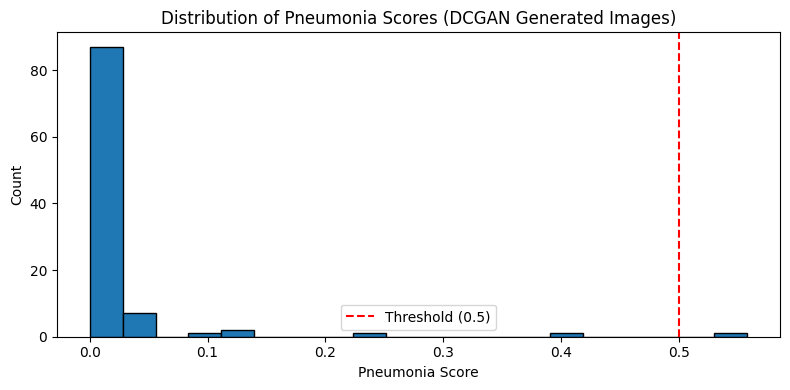

In [68]:
# histogram of pneumonia scores
plt.figure(figsize=(8, 4))
plt.hist(pneumonia_scores, bins=20, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Pneumonia Score')
plt.ylabel('Count')
plt.title('Distribution of Pneumonia Scores (DCGAN Generated Images)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pneumonia_scores.png", dpi=150)
plt.show()

## Export (images/ + labels.csv + metrics.json)

In [69]:
# create labels dataframe
labels_df = pd.DataFrame({
    'filename': [p.name for p in generated_paths],
    'pneumonia_score': pneumonia_scores,
    'predicted_label': ['pneumonia' if s > threshold else 'normal' for s in pneumonia_scores]
})

# add all pathology scores
for i, name in enumerate(pathology_names):
    labels_df[name] = predictions[:, i]

labels_path = OUTPUT_DIR / "labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"Saved labels to {labels_path}")

labels_df.head()

Saved labels to outputs/02_dcgan/labels.csv


,filename,pneumonia_score,predicted_label,Atelectasis,Consolidation,Infiltration,Pneumothorax,Edema,Emphysema,Fibrosis,...,Pneumonia,Pleural_Thickening,Cardiomegaly,Nodule,Mass,Hernia,Lung Lesion,Fracture,Lung Opacity,Enlarged Cardiomediastinum
0,0000.png,0.000135,normal,0.237333,0.521934,0.581410,0.511968,0.008977,0.116430,0.503917,...,0.000135,0.519674,0.341707,0.512825,0.547708,0.063487,0.067576,0.501206,0.968125,0.531833
1,0001.png,0.016551,normal,0.515229,0.621898,0.600176,0.510634,0.100188,0.500163,0.547912,...,0.016551,0.551295,0.504487,0.552444,0.742098,0.001633,0.115941,0.500245,0.976374,0.605952
2,0002.png,0.003306,normal,0.387082,0.519297,0.507244,0.502892,0.006916,0.500682,0.546933,...,0.003306,0.534164,0.090791,0.528844,0.708723,0.020815,0.030895,0.504151,0.894216,0.524077
3,0003.png,0.039449,normal,0.504826,0.569732,0.622788,0.505947,0.072493,0.481918,0.560812,...,0.039449,0.544932,0.278266,0.532290,0.640990,0.007617,0.024250,0.502058,0.957250,0.524635
4,0004.png,0.000321,normal,0.416731,0.525571,0.524893,0.500225,0.008230,0.144404,0.541004,...,0.000321,0.559710,0.501488,0.551783,0.723807,0.158539,0.177245,0.524406,0.922016,0.540801


In [70]:
# save metrics
metrics = {
    'model': 'dcgan',
    'n_generated': len(generated_paths),
    'fid_domain_adapted': fid_score,
    'tstr_accuracy': tstr_accuracy,
    'mean_pneumonia_score': float(pneumonia_scores.mean()),
    'epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'noise_dim': NOISE_DIM,
    'learning_rate': LR,
    'final_G_loss': G_losses[-1] if G_losses else None,
    'final_D_loss': D_losses[-1] if D_losses else None,
    'seed': SEED
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to outputs/02_dcgan/metrics.json
{
  "model": "dcgan",
  "n_generated": 100,
  "fid_domain_adapted": 15.236084861772152,
  "tstr_accuracy": 1.0,
  "mean_pneumonia_score": 0.020715655758976936,
  "epochs": 50,
  "batch_size": 32,
  "noise_dim": 100,
  "learning_rate": 0.0002,
  "final_G_loss": 5.713233771402974,
  "final_D_loss": 0.19273812197579826,
  "seed": 42
}


## Results

**Summary:**

In [71]:
print("="*50)
print("DCGAN RESULTS")
print("="*50)
print(f"Images generated: {len(generated_paths)}")
print(f"Training epochs: {N_EPOCHS}")
print(f"Domain-adapted FID: {fid_score:.2f}")
print(f"Proxy TSTR accuracy: {tstr_accuracy:.1f}%")
print(f"Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"Final G loss: {G_losses[-1]:.4f}")
print(f"Final D loss: {D_losses[-1]:.4f}")
print("="*50)
print(f"Outputs saved to: {OUTPUT_DIR}")
print(f"  - images/: {len(generated_paths)} PNG files")
print(f"  - labels.csv")
print(f"  - metrics.json")
print(f"  - checkpoints/: saved every 10 epochs")

DCGAN RESULTS
Images generated: 100
Training epochs: 50
Domain-adapted FID: 15.24
Proxy TSTR accuracy: 1.0%
Mean pneumonia score: 0.021
Final G loss: 5.7132
Final D loss: 0.1927
Outputs saved to: outputs/02_dcgan
  - images/: 100 PNG files
  - labels.csv
  - metrics.json
  - checkpoints/: saved every 10 epochs
